In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
print("Missing values in train:", np.isnan(X_train).sum())
print("Duplicates in train:", pd.DataFrame(X_train.reshape(X_train.shape[0], -1)).duplicated().sum())

Missing values in train: 0
Duplicates in train: 0


In [4]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

mean = np.mean(X_train)
std  = np.std(X_train)

In [5]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

In [6]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

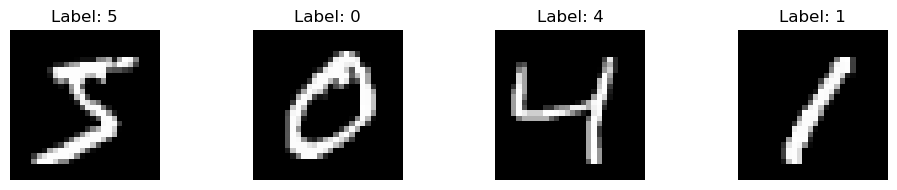

In [7]:
def show_examples(images, labels, num=4):
    plt.figure(figsize=(10, 2))
    for i in range(num):
        plt.subplot(1, num, i+1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.tight_layout()
show_examples(X_train, y_train)

In [15]:
mean = np.mean(X_train)
std  = np.std(X_train)

# Function to standardize
def standardize(x):
    return (x - mean) / std

# Apply standardization
X_train_std = standardize(X_train)
X_test_std  = standardize(X_test)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 3.1 Define the model
model = Sequential()

# First convolutional block
model.add(Conv2D(64, (3,3), activation="relu", input_shape=(28,28,1)))
model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))

# Second convolutional block
model.add(Conv2D(128, (3,3), activation="relu"))
model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))

# Third convolutional block
model.add(Conv2D(256, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))

# Fully connected layers
model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dense(10, activation="softmax"))

# Compile the model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690,890 (2.64 MB)

 Trainable params: 690,890 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(X_train_std, y_train_cat,
                    epochs=1,
                    batch_size=16,
                    verbose=1,
                    validation_split=0.1)


3375/3375 ━━━━━━━━━━━━━━━━━━━━ 156s 45ms/step - accuracy: 0.9632 - loss: 0.1204 - val_accuracy: 0.9915 - val_loss: 0.0329


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


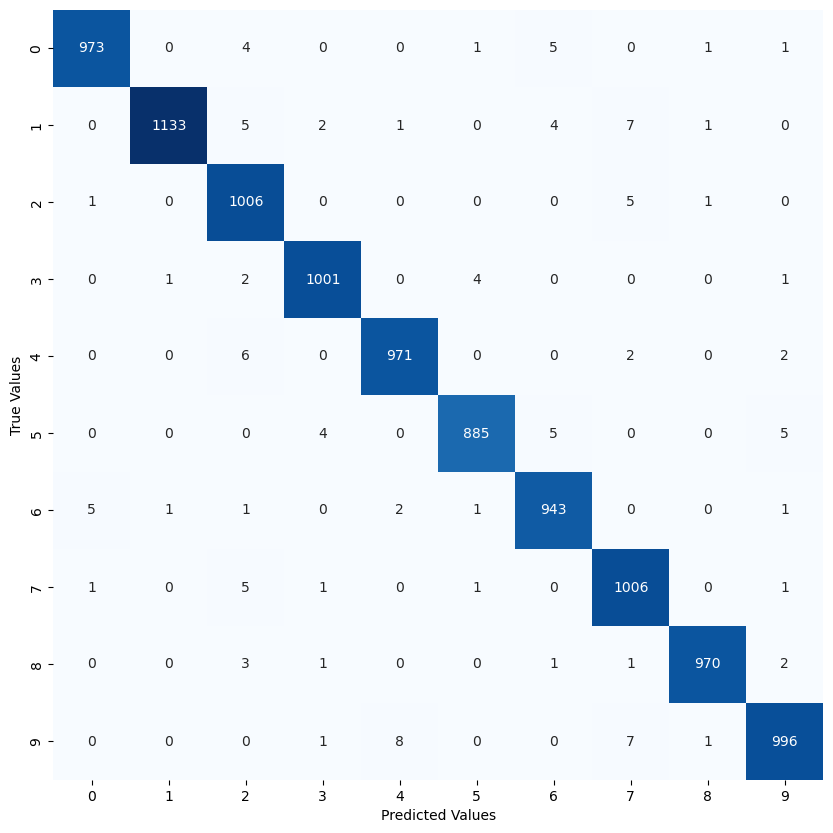

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      1.00      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [18]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test_std)
Y_pred = np.argmax(y_pred, axis=1)
Y_test = np.argmax(y_test_cat, axis=1)

mat = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(10,10))
sns.heatmap(mat.T, square=True, annot=True, cbar=False, cmap=plt.cm.Blues, fmt='.0f')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()

# Classification report
print(classification_report(Y_test, Y_pred))


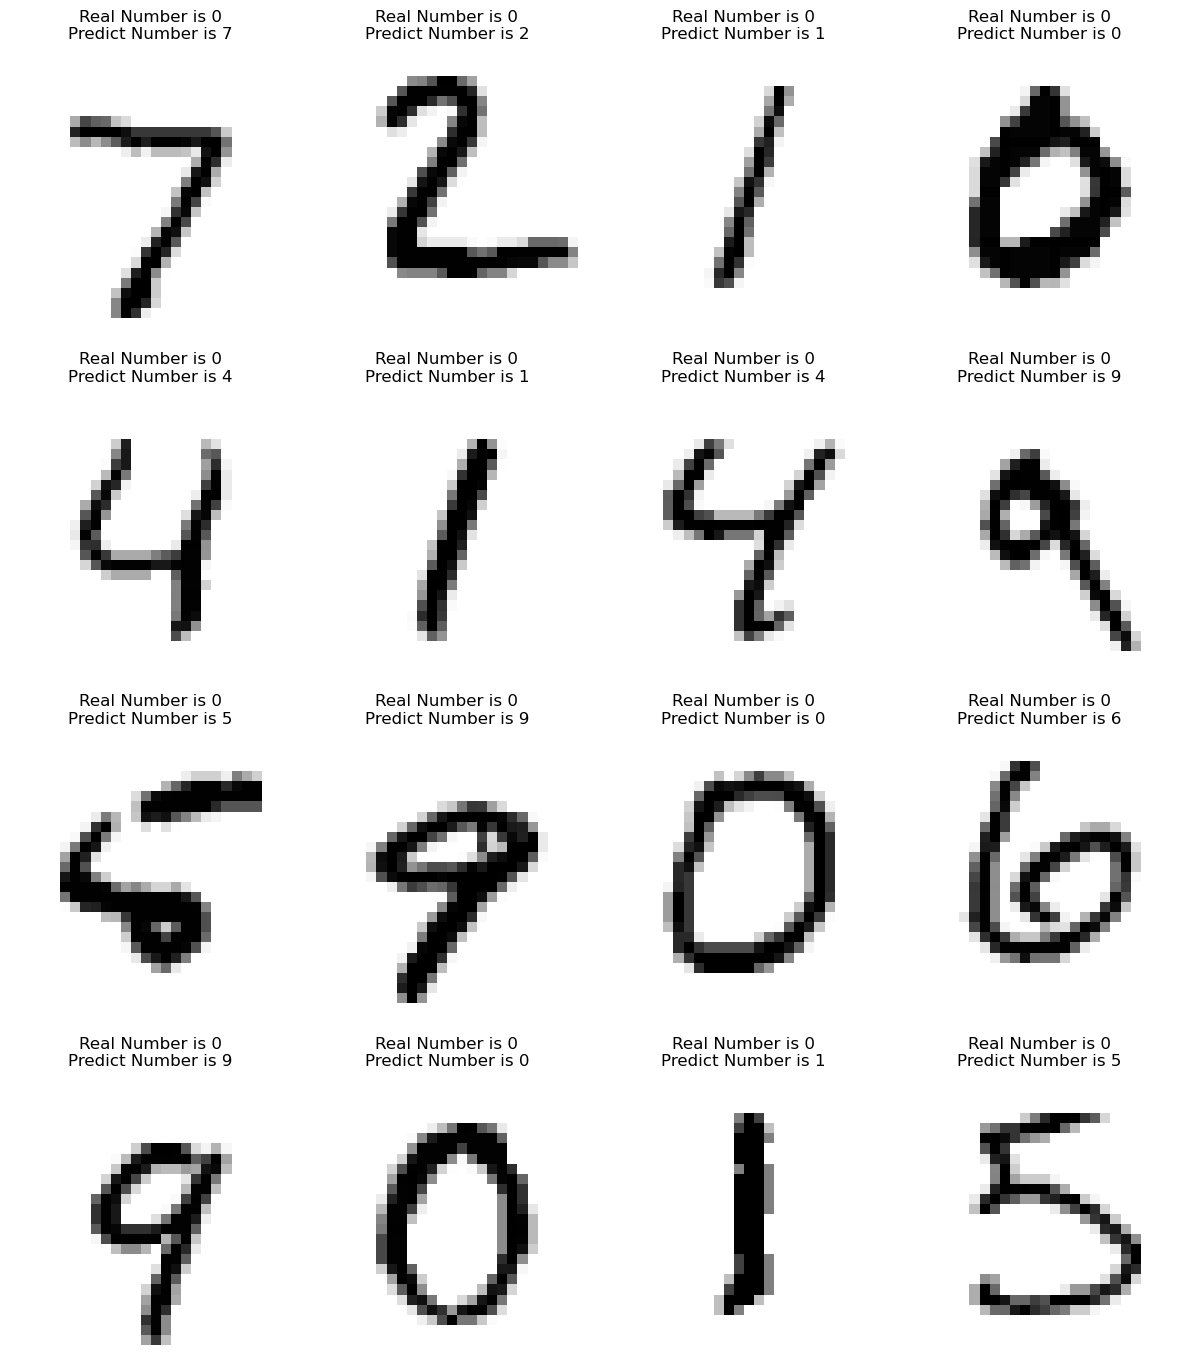

In [19]:
X_test_ = X_test_std.reshape(X_test_std.shape[0], 28, 28)

fig, axis = plt.subplots(4, 4, figsize=(12, 14))
for i, ax in enumerate(axis.flat):
    ax.imshow(X_test_[i], cmap='binary')
    ax.set(title=f"Real Number is {y_test[i].argmax()}\nPredict Number is {y_pred[i].argmax()}")
    ax.axis('off')
plt.tight_layout()
plt.show()